# Предсказание удоя и вкуса молока коров

Фермер, владелец молочного хозяйства «Вольный луг», хочет купить коров, чтобы расширить поголовье стада коров. Для этого он заключил выгодный контракт с ассоциацией пастбищ «ЭкоФерма».

Условия позволяют фермеру очень тщательно отобрать коров. Он определяет качество молока по строгой методике, и при этом ему нужно выполнять свой план развития молочного хозяйства. Фермер хочет, чтобы каждая корова давала не менее 6000 килограммов молока в год, а её надой был вкусным — строго по его критериям, ничуть не хуже. А продавцы и технологи так и норовят приукрасить своих коровок.

Необходимо разработать модель машинного обучения, которая поможет ему управлять рисками и принимать объективное решение о покупке. «ЭкоФерма» готова предоставить подробные данные о своих коровах. Нужно создать две прогнозные модели для отбора коров в поголовье:

1. Первая будет прогнозировать возможный удой коровы (целевой признак Удой);
2. Вторая — рассчитывать вероятность получить вкусное молоко от коровы (целевой признак Вкус молока).

С помощью модели нужно отобрать коров по двум критериям:
- средний удой за год — не менее 6000 килограммов;
- молоко должно быть вкусным.

Импортирование библиотек

In [71]:
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    root_mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    confusion_matrix,
    recall_score,
    precision_score,
    confusion_matrix
)

try:
    import phik
except:
    !pip install phik -q
    import phik

warnings.filterwarnings('ignore')

## Загрузка данных

In [72]:
ferma_main = pd.read_csv('ferma_main.csv', sep=';', decimal=',')
ferma_dad = pd.read_csv('ferma_dad.csv', sep=';')
cow_buy = pd.read_csv('cow_buy.csv', sep=';', decimal=',')

In [73]:
display(ferma_main.head(10))
display(ferma_dad.head(10))
cow_buy.head(10)

,id,"Удой, кг",ЭКЕ (Энергетическая кормовая единица),"Сырой протеин, г",СПО (Сахаро-протеиновое соотношение),Порода,Тип пастбища,порода папы_быка,"Жирность,%","Белок,%",Вкус молока,Возраст
0,1,5863,14.2,1743,0.890,Вис Бик Айдиал,Равнинное,Айдиал,3.58,3.076,вкусно,более_2_лет
1,2,5529,12.8,2138,0.890,Вис Бик Айдиал,Равнинные,Соверин,3.54,3.079,вкусно,менее_2_лет
2,3,5810,14.0,1854,0.885,РефлешнСоверинг,Холмистое,Соверин,3.59,3.074,не вкусно,более_2_лет
3,4,5895,12.4,2012,0.885,РефлешнСоверинг,Холмистое,Айдиал,3.40,3.075,не вкусно,более_2_лет
4,5,5302,12.8,1675,0.885,Вис Бик Айдиал,Равнинные,Соверин,3.73,3.073,вкусно,менее_2_лет
5,6,5254,12.7,1806,0.885,РефлешнСоверинг,Холмистое,Соверин,3.13,3.078,вкусно,менее_2_лет
6,7,5910,13.2,1792,0.885,Вис Бик Айдиал,Равнинные,Соверин,3.48,3.077,вкусно,более_2_лет
7,8,6179,14.7,1806,0.930,Вис Бик Айдиал,Равнинные,Айдиал,3.55,3.076,вкусно,более_2_лет
8,9,6783,14.2,1918,0.940,РефлешнСоверинг,Холмистое,Айдиал,3.71,3.077,вкусно,более_2_лет
9,10,5339,13.4,1791,0.895,Вис Бик Айдиал,Холмистое,Соверин,3.13,3.075,вкусно,менее_2_лет


,id,Имя Папы
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин
5,6,Барин
6,7,Соловчик
7,8,Геркулес
8,9,Буйный
9,10,Барин


,Порода,Тип пастбища,порода папы_быка,Имя_папы,"Текущая_жирность,%","Текущий_уровень_белок,%",Возраст
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет
5,РефлешнСоверинг,равнинное,Соверин,Геркулес,3.63,3.053,менее_2_лет
6,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет
7,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.57,3.079,более_2_лет
8,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет
9,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.079,менее_2_лет


Выведем общую информацию о всех таблицах

In [74]:
display(ferma_main.info())
display(ferma_dad.info())
cow_buy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 12 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     634 non-null    int64  
 1   Удой, кг                               634 non-null    int64  
 2   ЭКЕ (Энергетическая кормовая единица)  634 non-null    float64
 3   Сырой протеин, г                       634 non-null    int64  
 4   СПО (Сахаро-протеиновое соотношение)   634 non-null    float64
 5   Порода                                 634 non-null    object 
 6   Тип пастбища                           634 non-null    object 
 7   порода папы_быка                       634 non-null    object 
 8   Жирность,%                             634 non-null    float64
 9   Белок,%                                634 non-null    float64
 10  Вкус молока                            634 non-null    object 
 11  Возрас

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        629 non-null    int64 
 1   Имя Папы  629 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.0+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Порода                   20 non-null     object 
 1   Тип пастбища             20 non-null     object 
 2   порода папы_быка         20 non-null     object 
 3   Имя_папы                 20 non-null     object 
 4   Текущая_жирность,%       20 non-null     float64
 5   Текущий_уровень_белок,%  20 non-null     float64
 6   Возраст                  20 non-null     object 
dtypes: float64(2), object(5)
memory usage: 1.2+ KB


Предварительно видно следующие проблемы:
- неудобные для работы названия столбцов
- неверные типы данных

##  Предобработка данных

### Переименование столбцов

Изменим наименования столбцов следующим образом:
- запишем всё латиницей
- все пробелы заменим на '_'
- убирём единицы измерений

In [75]:
ferma_main.columns = ['id', 'milk_kg', 'ake', 'raw_protein', 'spo', 'breed', 'pasture_type',
                    'father_breed', 'fat', 'protein', 'milk_taste', 'age']
ferma_dad.columns = ['id', 'father_name']
cow_buy.columns = ['breed', 'pasture_type', 'father_breed', 'father_name', 'fat', 'protein', 'age']

### Обработка пропусков и неявных дубликатов

Выведем уникальные значения категориальных столбцов всех таблиц

In [76]:
for i in ferma_main.select_dtypes(include=['object']).columns.tolist():
    print(i)
    print('ferma_main: ', ferma_main[i].unique())
    if i in cow_buy.columns:
        print('cow_buy: ', cow_buy[i].unique())
    print('___')
print('ferma_dad: ', ferma_dad['father_name'].unique())
print('___')

breed
ferma_main:  ['Вис Бик Айдиал' 'РефлешнСоверинг']
cow_buy:  ['Вис Бик Айдиал' 'РефлешнСоверинг']
___
pasture_type
ferma_main:  ['Равнинное' 'Равнинные' 'Холмистое']
cow_buy:  ['холмистое' 'равнинное']
___
father_breed
ferma_main:  ['Айдиал' 'Соверин' 'Айдиалл']
cow_buy:  ['Айдиал' 'Соверин']
___
milk_taste
ferma_main:  ['вкусно' 'не вкусно']
___
age
ferma_main:  ['более_2_лет' 'менее_2_лет']
cow_buy:  ['более_2_лет' 'менее_2_лет']
___
ferma_dad:  ['Буйный' 'Соловчик' 'Барин' 'Геркулес']
___


Пропусков в категориальных значениях нет, но видны неявные дубликаты.

- порода `айдиал` записана в трёх вариантах: `Вис Бик Айдиал`, `Айдиал` и `Айдиалл`. Оставим `айдиал`
- порода `соверинг` записана в двух вариантах: `РефлешнСоверинг` и `Соверин`. Оставим `соверин`
- тип пастбища `холмистое` записан в двух вариантах: `Холмистое` и `холмистое`. Оставим `холмистое`
- тип пастбища `равнинное` записан в трёх вариантах: `Равнинное`, `Равнинные`, `равнинное`. Оставим `равнинное`

In [77]:
ferma_main['breed'] = ferma_main['breed'].str.replace('Вис Бик Айдиал', 'айдиал').replace('РефлешнСоверинг', 'соверин')
ferma_main['pasture_type'] = (
    ferma_main['pasture_type'].str
    .replace('Равнинное', 'равнинное')
    .replace('Равнинные', 'равнинное')
    .replace('Холмистое', 'холмистое')
)
ferma_main['father_breed'] = (
    ferma_main['father_breed'].str
    .replace('Айдиалл', 'айдиал')
    .replace('Айдиал', 'айдиал')
    .replace('Соверин', 'соверин')
)

cow_buy.loc[:, 'breed'] = cow_buy['breed'].str.replace('Вис Бик Айдиал', 'айдиал').replace('РефлешнСоверинг', 'соверин')
cow_buy.loc[:, 'father_breed'] = (
    cow_buy['father_breed'].str
    .replace('Айдиал', 'айдиал')
    .replace('Соверин', 'соверин')
)

Проверим

In [78]:
for i in ferma_main.select_dtypes(include=['object']).columns.tolist():
    print(i)
    print('ferma_main: ', ferma_main[i].unique())
    if i in cow_buy.columns:
        print('cow_buy: ', cow_buy[i].unique())
    print('___')
print('ferma_dad: ', ferma_dad['father_name'].unique())
print('___')

breed
ferma_main:  ['айдиал' 'соверин']
cow_buy:  ['айдиал' 'соверин']
___
pasture_type
ferma_main:  ['равнинное' 'холмистое']
cow_buy:  ['холмистое' 'равнинное']
___
father_breed
ferma_main:  ['айдиал' 'соверин']
cow_buy:  ['айдиал' 'соверин']
___
milk_taste
ferma_main:  ['вкусно' 'не вкусно']
___
age
ferma_main:  ['более_2_лет' 'менее_2_лет']
cow_buy:  ['более_2_лет' 'менее_2_лет']
___
ferma_dad:  ['Буйный' 'Соловчик' 'Барин' 'Геркулес']
___


### Обработка явных дубликатов

Найдём кол-во дубликатов в таблицах

In [79]:
print('ferma_main duplicated: ', ferma_main.duplicated().sum())
print('ferma_dad duplicated: ', ferma_dad.duplicated().sum())
print('cow_buy duplicated: ', cow_buy.duplicated().sum())

ferma_main duplicated:  5
ferma_dad duplicated:  0
cow_buy duplicated:  4


Выведем эти дубликаты

In [80]:
display(ferma_main[ferma_main.duplicated()])
cow_buy[cow_buy.duplicated()]

,id,milk_kg,ake,raw_protein,spo,breed,pasture_type,father_breed,fat,protein,milk_taste,age
629,627,5970,14.4,1837,0.88,соверин,холмистое,соверин,3.64,3.075,не вкусно,более_2_лет
630,627,5970,14.4,1837,0.88,соверин,холмистое,соверин,3.64,3.075,не вкусно,более_2_лет
631,627,5970,14.4,1837,0.88,соверин,холмистое,соверин,3.64,3.075,не вкусно,более_2_лет
632,627,5970,14.4,1837,0.88,соверин,холмистое,соверин,3.64,3.075,не вкусно,более_2_лет
633,627,5970,14.4,1837,0.88,соверин,холмистое,соверин,3.64,3.075,не вкусно,более_2_лет


,breed,pasture_type,father_breed,father_name,fat,protein,age
6,айдиал,холмистое,айдиал,Геркулес,3.58,3.076,более_2_лет
8,соверин,равнинное,соверин,Барин,3.59,3.074,более_2_лет
14,соверин,равнинное,соверин,Барин,3.59,3.074,более_2_лет
19,соверин,равнинное,айдиал,Буйный,3.64,3.074,более_2_лет


Удалим явные дубликаты в `ferma_main`

В `cow_buy` явные дубликаты оставим т. к. выборка и так небольшая

In [81]:
ferma_main = ferma_main.drop_duplicates()

Проверим

In [82]:
print('ferma_main duplicated: ', ferma_main.duplicated().sum())
print('ferma_dad duplicated: ', ferma_dad.duplicated().sum())
print('cow_buy duplicated: ', cow_buy.duplicated().sum())

ferma_main duplicated:  0
ferma_dad duplicated:  0
cow_buy duplicated:  4


### Вывод

В таблицах `ferma_main` присутствуют дублирующиеся строки, что скорее всего вызвано технической ошибкой. В столбцах с породами коров и типами пастбищ есть неявные дубликаты, что скорее всего вызвано человеческим фактором, заказчику рекомендуется более ответственно подходитиь к унификации вышеупомянутых данных.

Что было сделано:
- Изменены названия столбцов
- Обработаны неявные дубликаты в столбцах пород и типов пастбищ
- Удалены дублирующиеся строки в таблицах `ferma_main`

## Исследовательский анализ данных

### Исследование отдельных признаков

In [83]:
# функция вывода характеристик количественного признака
def feature_stat_quant(feature, title, ylabel, bins_count=50):
    fig, axes = plt.subplots(ncols=1, nrows=2, gridspec_kw={'height_ratios' : [15, 85]}, figsize=(8, 5), sharex=True)
    axes[0].boxplot(feature, vert=False)
    axes[0].set_title(title)
    
    axes[1].hist(feature, bins=bins_count)
    axes[1].set_ylabel(ylabel)
    axes[1].axvline(feature.mean(), color='red', linestyle='-', linewidth=2, label=f'Среднее: {feature.mean():.2f}')
    axes[1].axvline(feature.median(), color='red', linestyle='--', linewidth=2, label=f'Медиана: {feature.median():.2f}')
    
    plt.tight_layout()
    plt.legend()
    plt.grid()
    plt.show()
    print(feature.describe().T)
    
# функция для построения графика категориальных переменных
def feature_stat_categ(xlabels, cols, title_name, vals_unique=[]):
    plt.figure(figsize=(10,6)) 
    
    if(len(vals_unique) == 0):
        for i in range(len(cols)):
            cols[i] = cols[i].sort_values()
        percent_list = [((col == val).sum() / col.size)*100 for col in cols for val in col.unique()]
    else:
        percent_list = []
        for i in range(len(cols)):
            for j in range(2):
                percent_list.append(((cols[i] == vals_unique[j]).sum() / cols[i].size)*100)
        
    bars = plt.bar(xlabels, percent_list,
              color=['blue','skyblue', 'red', 'lightcoral', 'green', 'lightgreen'], alpha=0.8, width=0.6)
    for i, v in enumerate(percent_list):
        plt.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom')
    plt.xticks(rotation=45)
    plt.title(title_name)
    plt.ylabel('%')
    plt.ylim(0, 110)
    plt.show()

In [84]:
display(ferma_main.head())
cow_buy.head()

,id,milk_kg,ake,raw_protein,spo,breed,pasture_type,father_breed,fat,protein,milk_taste,age
0,1,5863,14.2,1743,0.890,айдиал,равнинное,айдиал,3.58,3.076,вкусно,более_2_лет
1,2,5529,12.8,2138,0.890,айдиал,равнинное,соверин,3.54,3.079,вкусно,менее_2_лет
2,3,5810,14.0,1854,0.885,соверин,холмистое,соверин,3.59,3.074,не вкусно,более_2_лет
3,4,5895,12.4,2012,0.885,соверин,холмистое,айдиал,3.40,3.075,не вкусно,более_2_лет
4,5,5302,12.8,1675,0.885,айдиал,равнинное,соверин,3.73,3.073,вкусно,менее_2_лет


,breed,pasture_type,father_breed,father_name,fat,protein,age
0,айдиал,холмистое,айдиал,Геркулес,3.58,3.076,более_2_лет
1,айдиал,равнинное,соверин,Буйный,3.54,3.081,менее_2_лет
2,соверин,равнинное,соверин,Барин,3.59,3.074,более_2_лет
3,соверин,холмистое,айдиал,Буйный,3.40,3.061,более_2_лет
4,соверин,равнинное,айдиал,Буйный,3.64,3.074,более_2_лет


#### Удой (`milk_kg`)

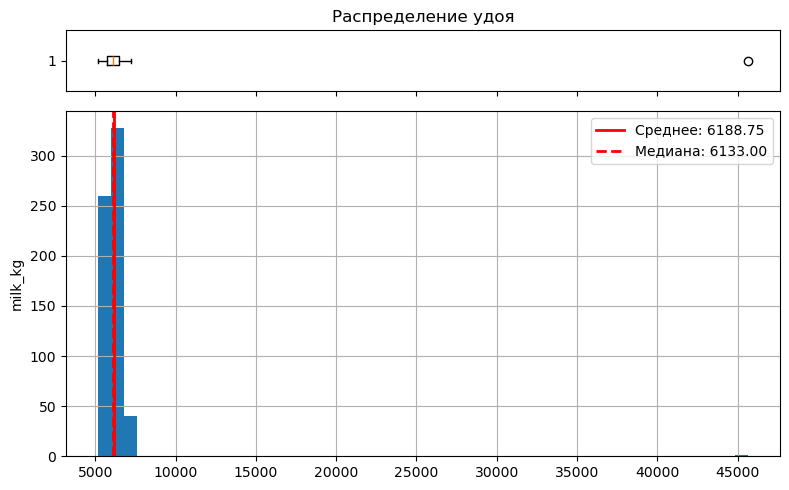

count      629.000000
mean      6188.750397
std       1644.795489
min       5204.000000
25%       5751.000000
50%       6133.000000
75%       6501.000000
max      45616.000000
Name: milk_kg, dtype: float64


In [85]:
feature_stat_quant(ferma_main['milk_kg'], 'Распределение удоя', 'milk_kg')

Есть сильные выбросы, выведем их

In [86]:
ferma_main.sort_values(by='milk_kg', ascending=False).head(5)

,id,milk_kg,ake,raw_protein,spo,breed,pasture_type,father_breed,fat,protein,milk_taste,age
16,17,45616,11.5,1675,0.93,айдиал,холмистое,айдиал,3.22,3.076,вкусно,более_2_лет
70,71,7222,16.8,2157,0.95,айдиал,холмистое,айдиал,3.70,3.076,вкусно,более_2_лет
135,136,7207,16.6,2343,0.94,айдиал,холмистое,айдиал,3.72,3.078,вкусно,более_2_лет
296,297,7201,15.8,2077,0.94,соверин,холмистое,айдиал,3.71,3.072,вкусно,более_2_лет
294,295,7197,15.6,2241,0.94,соверин,холмистое,айдиал,3.71,3.075,вкусно,более_2_лет


Одна из коров дала 45616 килограмм молока за год, выглядит нереалистично, удалим выброс

In [87]:
ferma_main = ferma_main.drop(ferma_main[ferma_main['milk_kg']>45000].index)

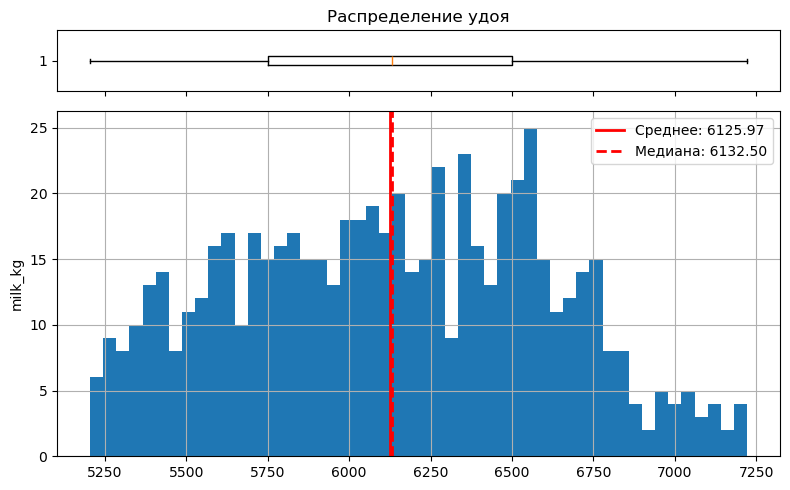

count     628.000000
mean     6125.968153
std       475.857053
min      5204.000000
25%      5749.750000
50%      6132.500000
75%      6501.000000
max      7222.000000
Name: milk_kg, dtype: float64


In [88]:
feature_stat_quant(ferma_main['milk_kg'], 'Распределение удоя', 'milk_kg')

Удой молока распределён нормально

#### Возраст (`age`)

Построим распределение возраста всех коровах и лучших в `ferma_main`, а также в `cow_buy`

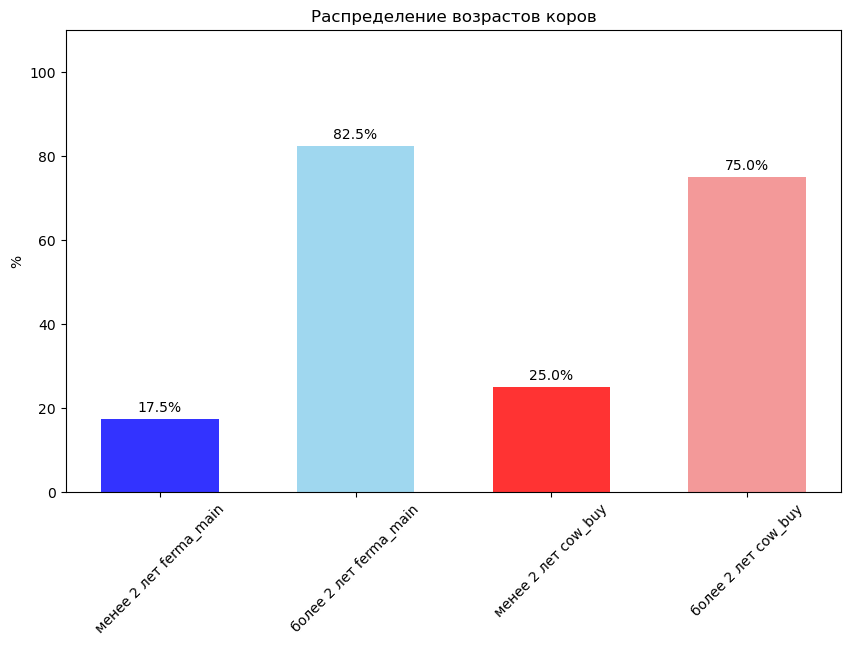

In [89]:
feature_stat_categ(['менее 2 лет ferma_main', 'более 2 лет ferma_main',
                    'менее 2 лет cow_buy', 'более 2 лет cow_buy'],
                  [ferma_main['age'], cow_buy['age']],
                  'Распределение возрастов коров', ['менее_2_лет', 'более_2_лет'])

Возраст большинства коров более 2 лет

#### ЭКЕ (Энергетическая кормовая единица) (`ake`)

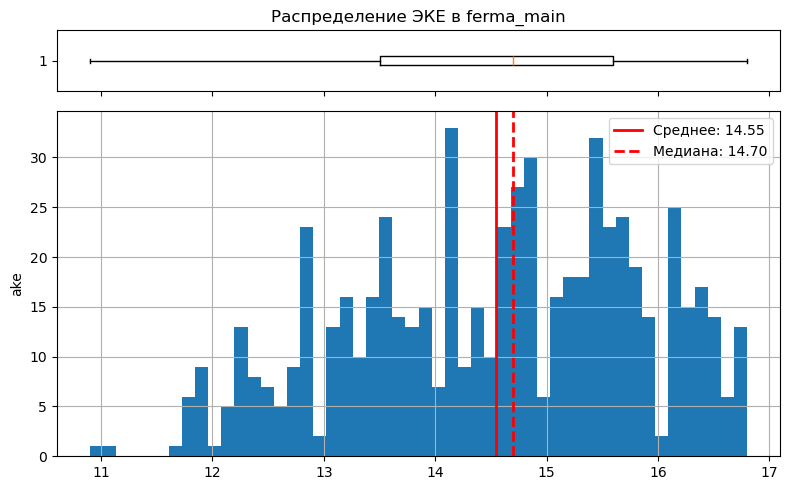

count    628.000000
mean      14.548726
std        1.301777
min       10.900000
25%       13.500000
50%       14.700000
75%       15.600000
max       16.800000
Name: ake, dtype: float64


In [90]:
feature_stat_quant(ferma_main['ake'], 'Распределение ЭКЕ в ferma_main', 'ake')

Значения `ЭКЕ` распределены более-менее нормально с небольшим смещением вправо

#### Сырой протеин (`raw_protein`)

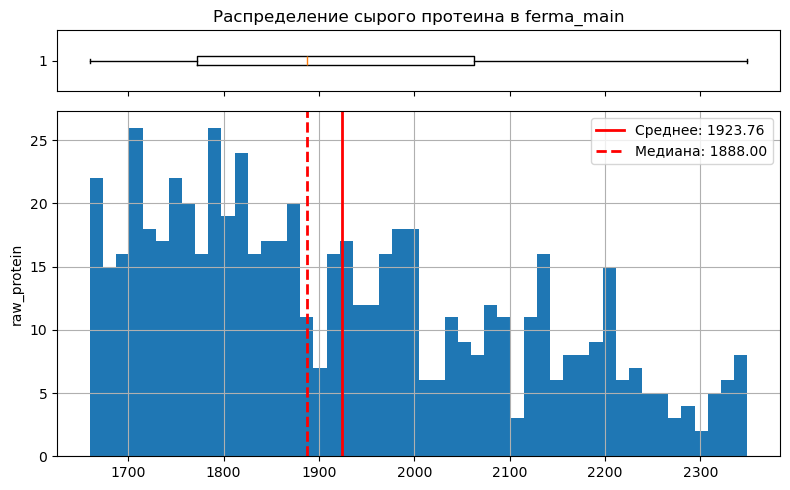

count     628.000000
mean     1923.759554
std       182.832816
min      1660.000000
25%      1771.750000
50%      1888.000000
75%      2062.250000
max      2349.000000
Name: raw_protein, dtype: float64


In [91]:
feature_stat_quant(ferma_main['raw_protein'], 'Распределение сырого протеина в ferma_main', 'raw_protein')

Сырой протеин распределён не нормально, смещён влево

#### Белок (`protein`)

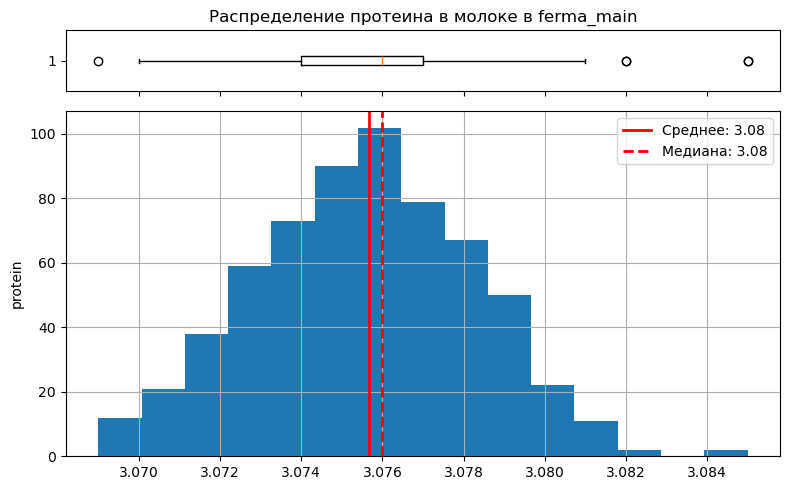

count    628.000000
mean       3.075670
std        0.002551
min        3.069000
25%        3.074000
50%        3.076000
75%        3.077000
max        3.085000
Name: protein, dtype: float64


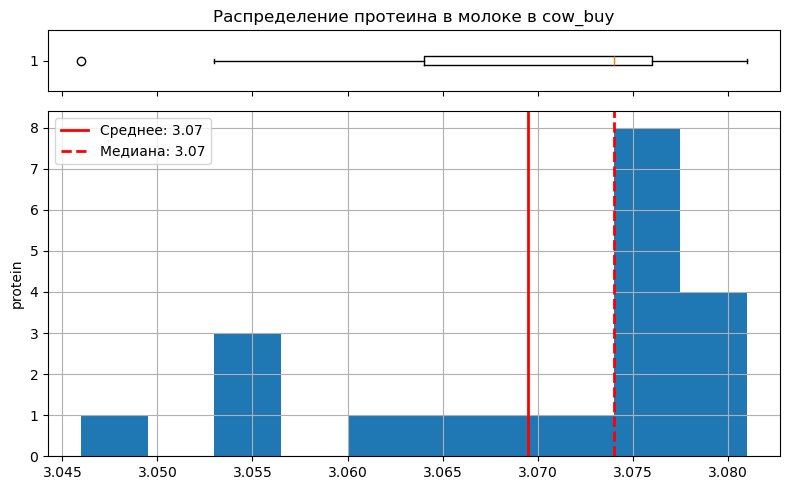

count    20.000000
mean      3.069500
std       0.010339
min       3.046000
25%       3.064000
50%       3.074000
75%       3.076000
max       3.081000
Name: protein, dtype: float64


In [92]:
feature_stat_quant(ferma_main['protein'], 'Распределение протеина в молоке в ferma_main', 'protein', len(ferma_main['protein'].unique()))
feature_stat_quant(cow_buy['protein'], 'Распределение протеина в молоке в cow_buy', 'protein', 10)

Распределение протеина в `ferma_main` нормальное, в `cow_buy` выбросов нет, данные расположены в тех же диапазонах, что и в `ferma_main`

#### СПО (Сахаро-протеиновое соотношение) (`spo`)

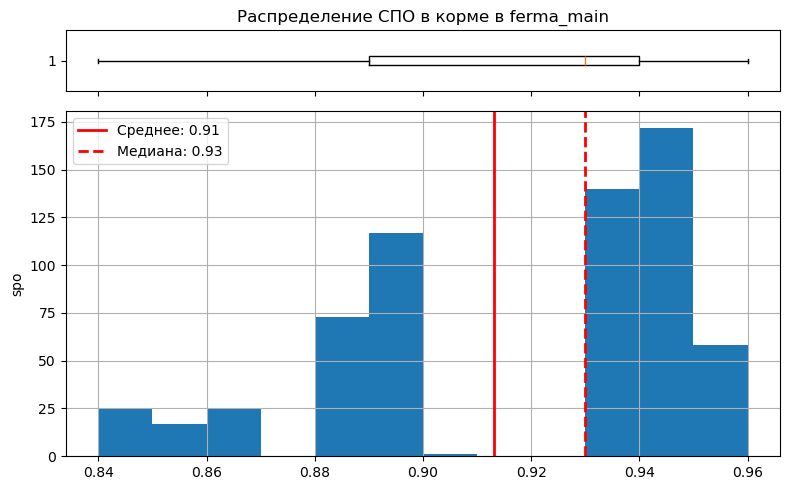

count    628.000000
mean       0.913089
std        0.032221
min        0.840000
25%        0.890000
50%        0.930000
75%        0.940000
max        0.960000
Name: spo, dtype: float64


In [93]:
feature_stat_quant(ferma_main['spo'], 'Распределение СПО в корме в ferma_main', 'spo', len(ferma_main['spo'].unique()))

В распределении `СПО` видно три отдельных группы значений

#### Порода (`breed`)

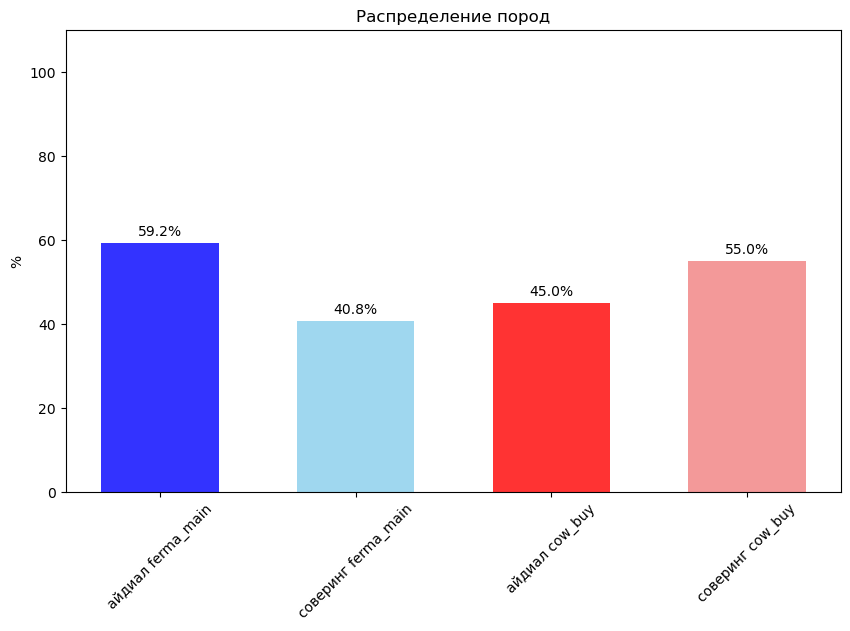

In [94]:
feature_stat_categ(['айдиал ferma_main', 'соверинг ferma_main',
                    'айдиал cow_buy', 'соверинг cow_buy'],
                  [ferma_main['breed'], cow_buy['breed']],
                  'Распределение пород')

В `ferma_main` немного больше коров породы `айдиал`, а в `cow_buy` практически поровну с небольшим отклонением в сторону `соверинг`

#### Тип пастбища (`pasture_type`)

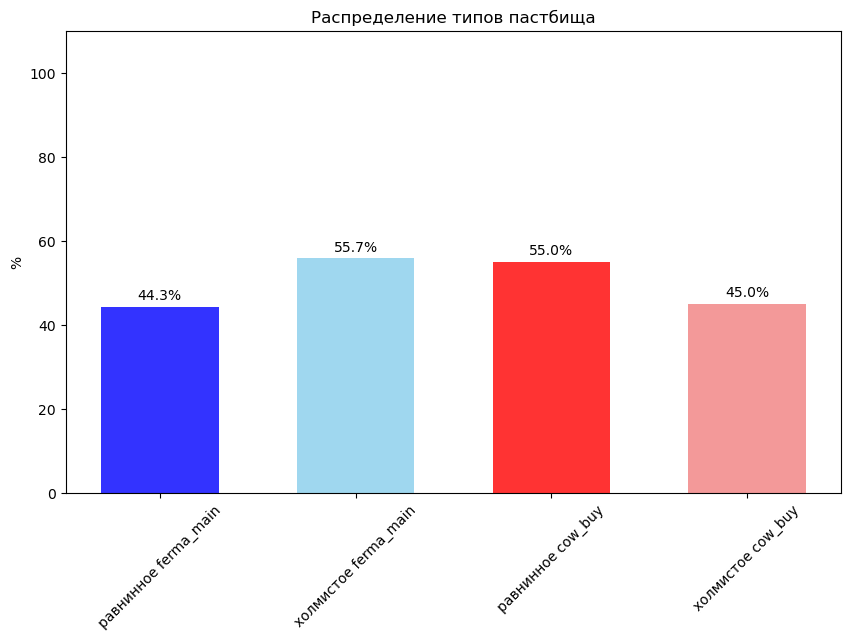

In [95]:
feature_stat_categ(['равнинное ferma_main', 'холмистое ferma_main',
                    'равнинное cow_buy', 'холмистое cow_buy'],
                  [ferma_main['pasture_type'], cow_buy['pasture_type']],
                  'Распределение типов пастбища')

В `ferma_main` и `cow_buy` распределение типов пастбищ довольно равномерное

#### Порода папы-быка (`father_breed`)

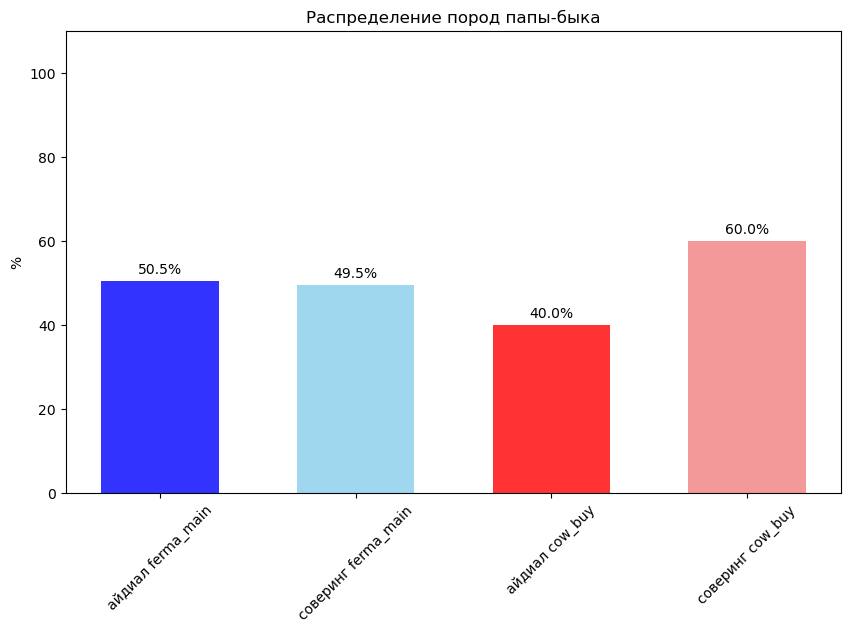

In [96]:
feature_stat_categ(['айдиал ferma_main', 'соверинг ferma_main',
                    'айдиал cow_buy', 'соверинг cow_buy'],
                  [ferma_main['father_breed'], cow_buy['father_breed']],
                  'Распределение пород папы-быка', ['айдиал', 'соверин'])

В основном породы отцов распределены равномерно

#### Жирность,% (`fat`)

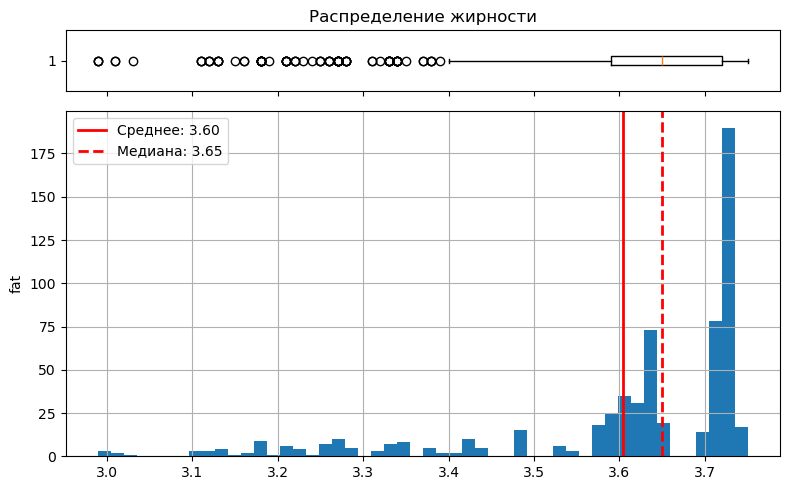

count    628.000000
mean       3.604268
std        0.168093
min        2.990000
25%        3.590000
50%        3.650000
75%        3.720000
max        3.750000
Name: fat, dtype: float64


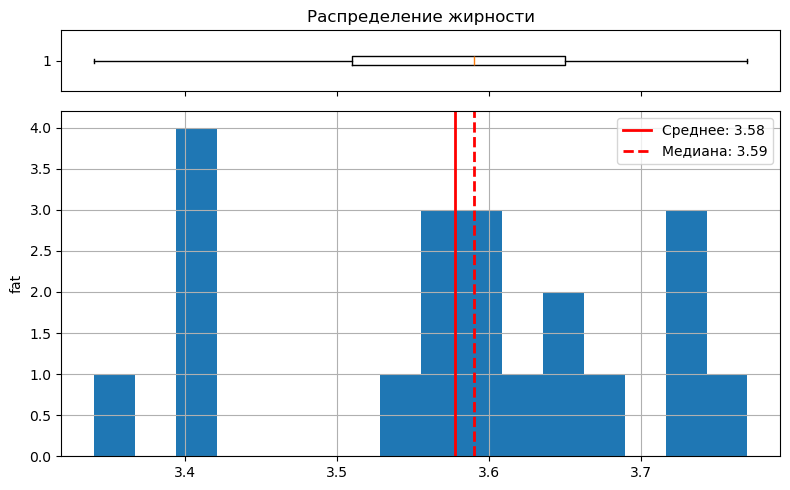

count    20.000000
mean      3.577500
std       0.126818
min       3.340000
25%       3.510000
50%       3.590000
75%       3.650000
max       3.770000
Name: fat, dtype: float64


In [97]:
feature_stat_quant(ferma_main['fat'], 'Распределение жирности', 'fat')
feature_stat_quant(cow_buy['fat'], 'Распределение жирности', 'fat', 16)

В `ferma_main` данные распределены от 3.0 до 3.75 с двумя боольшими пиками около 3.6 и 3.7. В `cow_buy` даннные распределены от 3.58 до 3.77

#### Вкус молока (`milk_taste`)

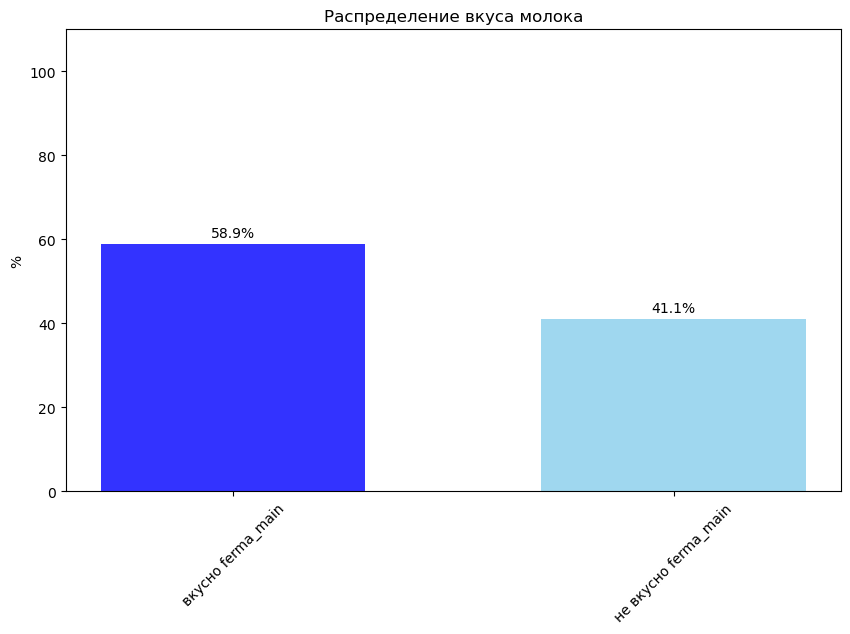

In [98]:
feature_stat_categ(['вкусно ferma_main', 'не вкусно ferma_main'],
                  [ferma_main['milk_taste']],
                  'Распределение вкуса молока')

В `ferma_main` распределение близко к равномерному с перевесом в сторону `вкусно`

### Вывод

В датасете была корова с аномально большим удоем, это скорее всего было вызвано человеческим фактором или технической ошибкой.

Из количественных признаков распределены нормально:
- удой (`milk_kg`)
- ЭКЕ (`ake`)
- белок (`protein`)

Ненормально:
- сырой протеин (`raw_protein`)
- СПО (`spo`)
- жирность (`fat`)

## Корреляционный анализ

### Расчёт коэффициента корреляции между всеми признаками

Построим тепловую карту коэффициентов корреляции методом `phik_matrix`

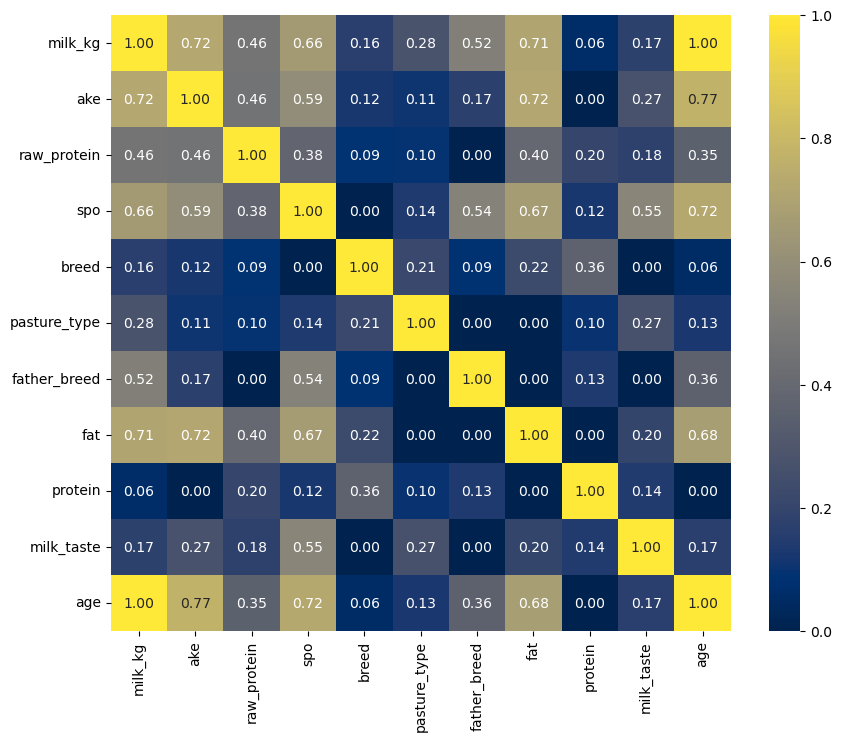

In [99]:
plt.figure(figsize=(10, 8))
sns.heatmap(ferma_main.drop('id', axis=1).phik_matrix(interval_cols=
                                             ['milk_kg', 'ake', 'raw_protein', 'fat', 'protein']
                                            ), annot=True, fmt='.2f', cmap='cividis')
plt.show()

У удоя (`milk_kg`) коэффициент корреляции больше 0.9 только с возрастом (`age`) $\implies$ мультиколлинеарности не наблюдается

### Построение диаграмм рассеяния с учётом категориальных признаков

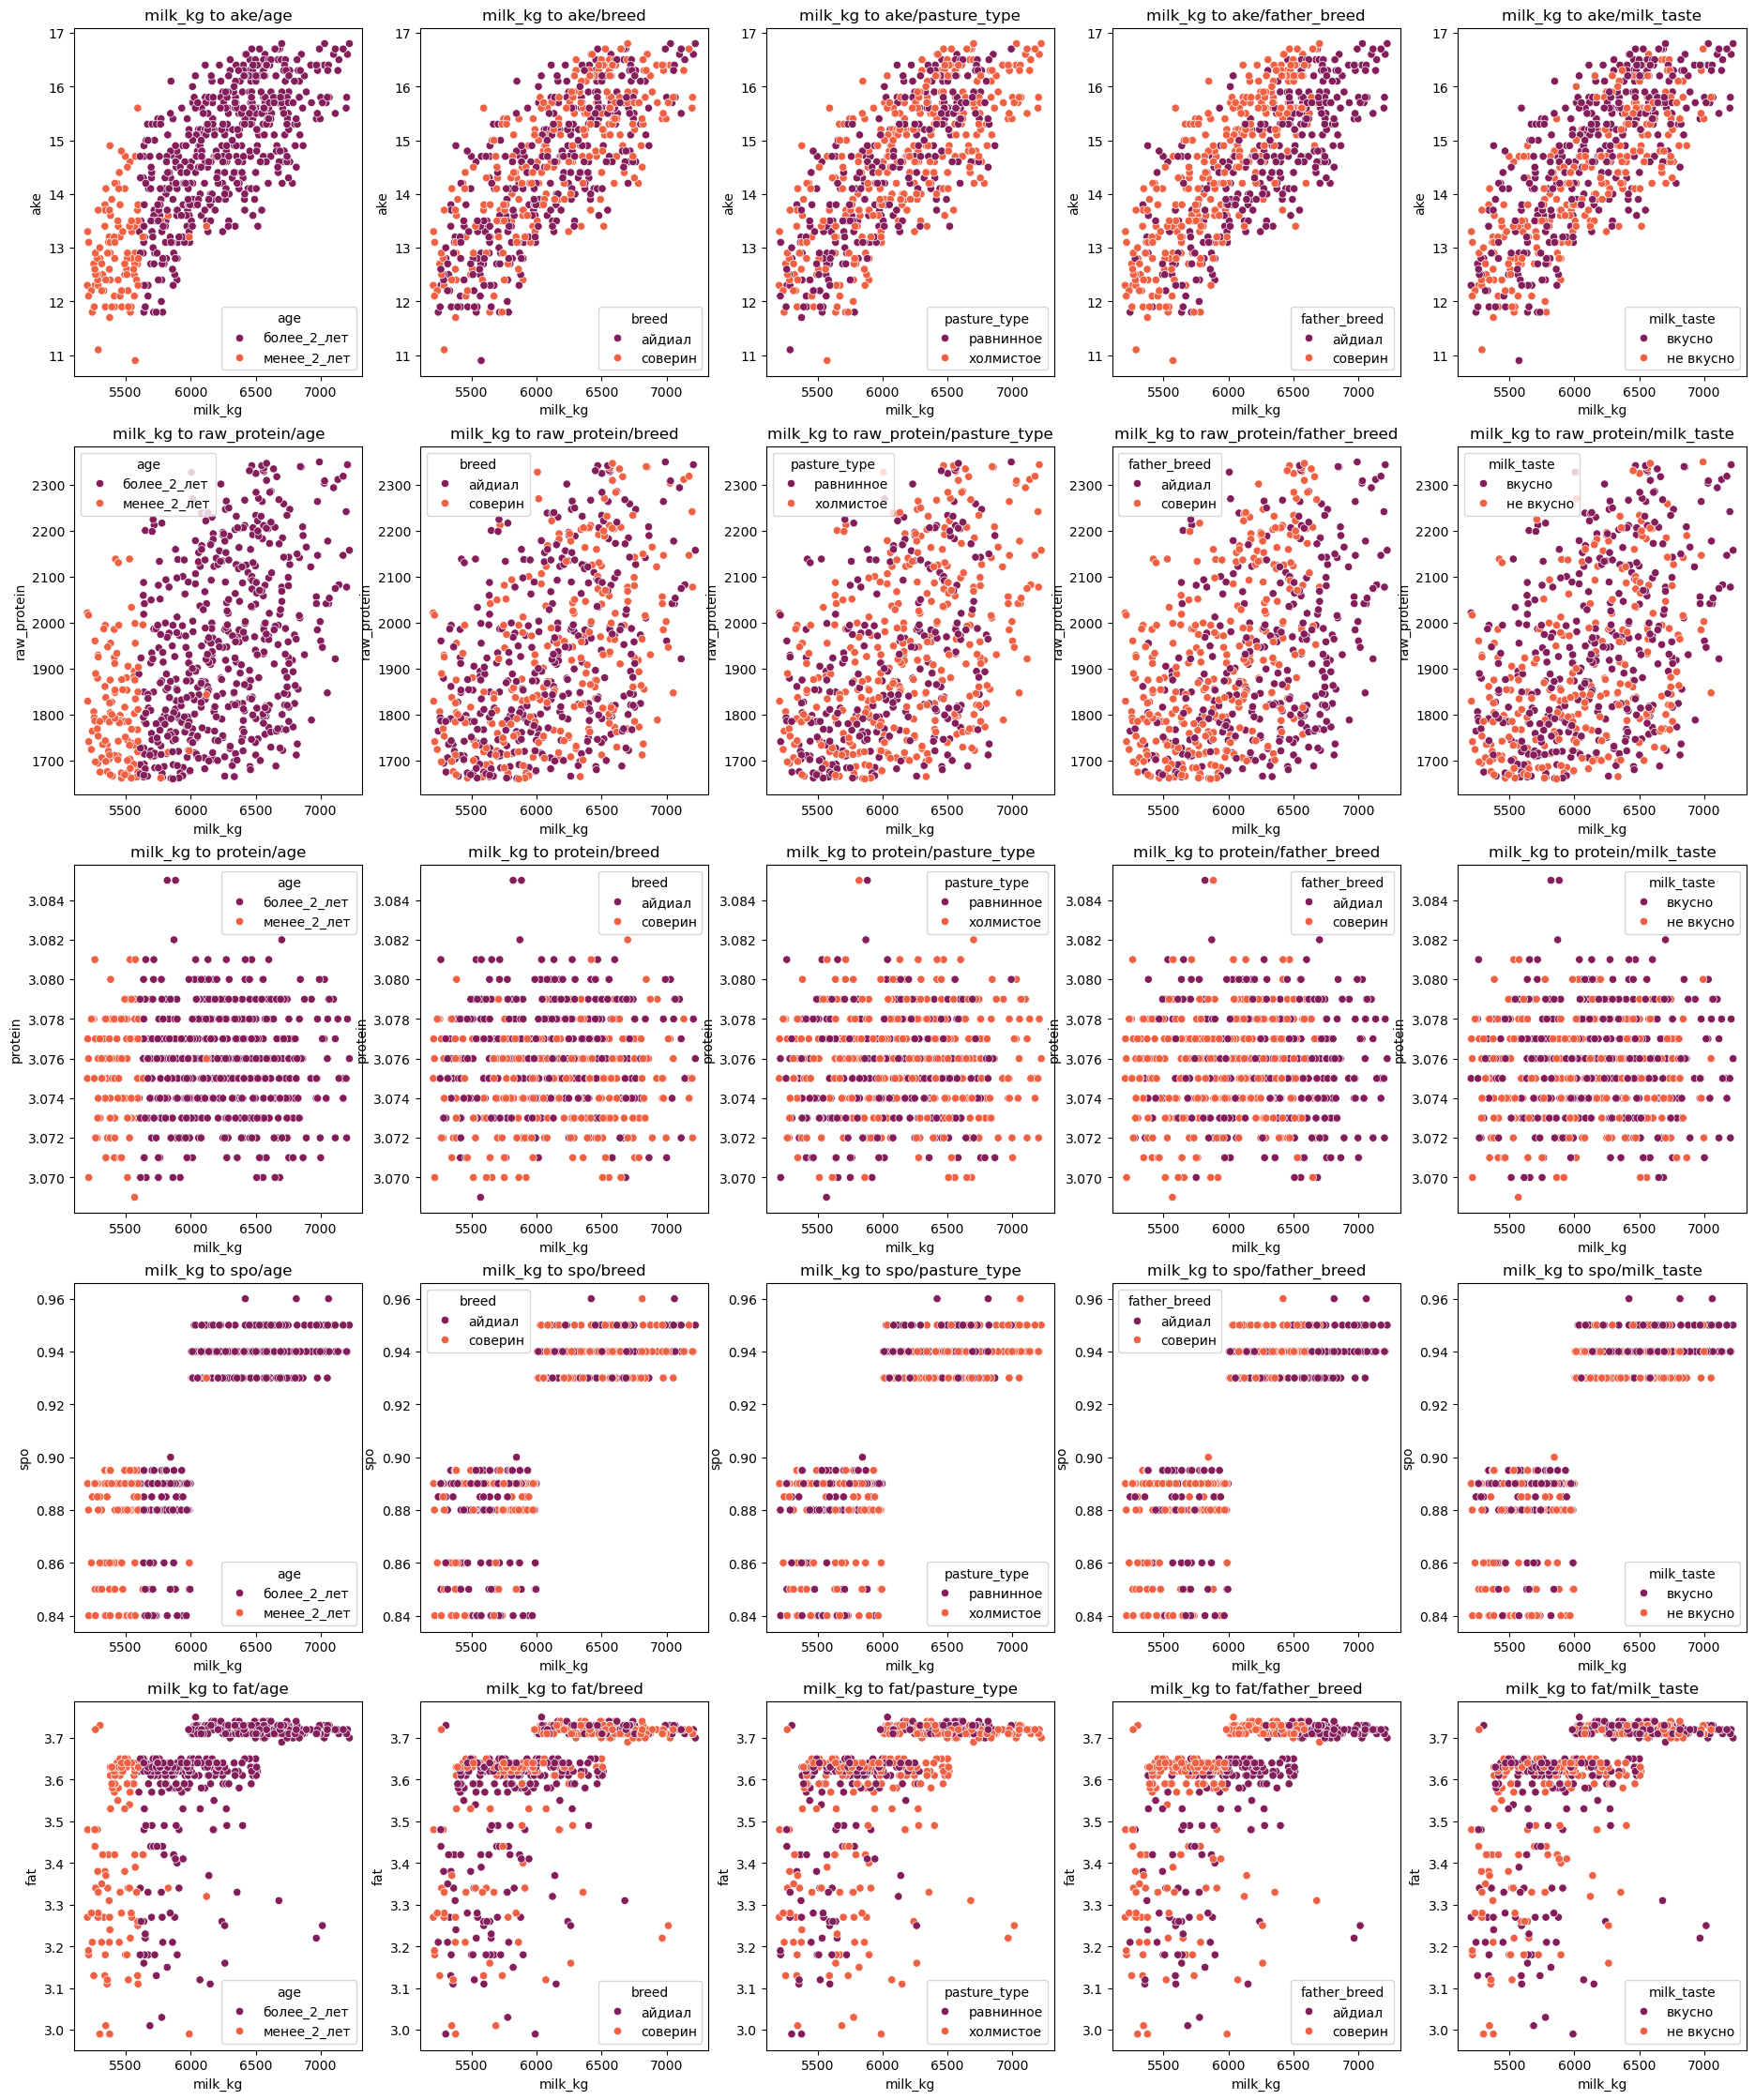

In [100]:
fig, axes = plt.subplots(5, 5, figsize=(23, 28))
axes = axes.flatten()

index = 0
for quant in ['ake', 'raw_protein', 'protein', 'spo', 'fat']:
    for categ in ['age', 'breed', 'pasture_type', 'father_breed', 'milk_taste']:
        sns.scatterplot(data=ferma_main.drop('id', axis=1), x='milk_kg', y=quant,
                    hue=categ, ax=axes[index], palette='rocket')
        axes[index].set_title(f'milk_kg to {quant}/{categ}')
        index += 1
plt.show()

По диаграммам рассеяния видны нелинейные связи с `spo` (данные сбиваются в два кластера) и с `protein`. В `ake` зависимость похожа на квадратичную

## Обучение модели линейной регрессии

In [101]:
# функция для обучения модели линейной регрессии и рассчёта метрики r2
def train_lr(df, cat_col_names, num_col_names, target_name):
    RANDOM_STATE = 42
    
    # разобьём данные на тренировочную и тестовую выборки
    X = df[cat_col_names + num_col_names]
    y = df[target_name]
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        random_state = RANDOM_STATE
    )
    
    # масштабирование количественных признаков
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train[num_col_names])
    X_test_scaled = scaler.transform(X_test[num_col_names])

    X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)
    
    # кодирование категориальных признаков
    encoder = OneHotEncoder(drop='first', sparse_output=False)
    X_train_ohe = encoder.fit_transform(X_train[cat_col_names])
    X_test_ohe = encoder.transform(X_test[cat_col_names])

    X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder.get_feature_names_out())
    X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder.get_feature_names_out())
    
    # объединим категориальные и количественные признаки
    X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
    X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)
    
    # обучение модели
    model_lr = LinearRegression()
    model_lr.fit(X_train, y_train)
    predictions = model_lr.predict(X_test)
    
    return predictions, y_test, r2_score(y_test, predictions), model_lr, scaler, encoder

In [102]:
# функция для построения графиков остатков
def residuals_plot(predictions, y_test):
    residuals = y_test - predictions

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
    axes[0].hist(residuals, bins=50)
    axes[0].set_title('Гистограмма распределения остатков')
    axes[0].set_xlabel('Остатки')
    axes[0].axvline(residuals.mean(), color='red', linestyle='-', linewidth=2, label=f'Среднее: {residuals.mean():.2f}')
    axes[0].axvline(0, color='black', linestyle='--', linewidth=2, label=f'0')
    axes[0].legend()

    axes[1].scatter(predictions, residuals)
    axes[1].set_xlabel('Предсказания модели')
    axes[1].set_ylabel('Остатки')
    axes[1].set_title('Анализ дисперсии')
    plt.show()

### Первая модель

Обучим первую модель на признаках корма и самой коровы:
- категориальных: `breed`, `pasture_type`, `father_breed`, `age`
- количественных: `ake`, `raw_protein`, `spo`

In [103]:
predictions_1, test_y_1, r2_1, model_lr_1, scaler_1, encoder_1 = train_lr(ferma_main,
         ['age', 'breed', 'pasture_type', 'father_breed'],
         ['ake', 'raw_protein', 'spo'], 'milk_kg')
print(f'r2 = {r2_1}')

r2 = 0.7844078173416967


Проанализируем остатки

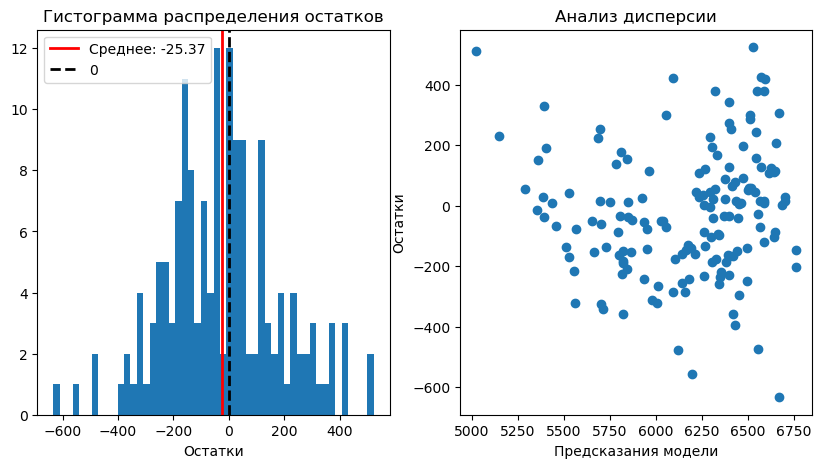

In [104]:
residuals_plot(predictions_1, test_y_1)

**Вывод**

- значение $r^2$ составляет 0.78, это означает, что в 78% случаев предсказание модели оказывается точнее среднего значения целевого признака
- распределение остатков близко к нормальному, среднее практически не сдвинуто относительно 0
- на графике дисперсии остатков видна область до 5800, в которой значения остатков меньше, для повышения точности возможно следует добавить дополнительные признаки или изменить взаимосвязь входных признаков с целевыми

### Вторая модель

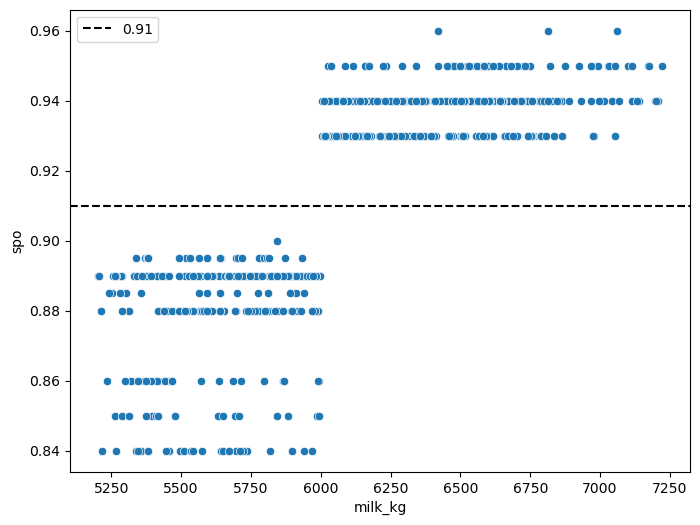

In [105]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=ferma_main.drop('id', axis=1), x='milk_kg', y='spo')
plt.axhline(y=0.91, color='black', linestyle='--', label='0.91')
plt.legend()
plt.show()

Как было сказано раньше, судя по диаграмме рассеяния `milk_kg` и `spo` связаны нелинейно. Можно заметить, что наблюдения сгруппированы в два кластера, которые чётко разделяются значением `spo` равным 0.91, следовательно можно преобразовать `spo` в бинарный категориальный признак со значениями `меньше_0_91` и `больше_0_91`

In [106]:
ferma_main['spo_bool'] = ferma_main['spo'] > 0.91

У удоя и ЭКЕ наблюдается квадратичная зависимость, добавим признак ЭКЕ$^2$ 

In [107]:
ferma_main['ake_squared'] = ferma_main['ake'] ** 2

Проверим

In [108]:
display(ferma_main.head(3))
ferma_main.info()

,id,milk_kg,ake,raw_protein,spo,breed,pasture_type,father_breed,fat,protein,milk_taste,age,spo_bool,ake_squared
0,1,5863,14.2,1743,0.890,айдиал,равнинное,айдиал,3.58,3.076,вкусно,более_2_лет,False,201.64
1,2,5529,12.8,2138,0.890,айдиал,равнинное,соверин,3.54,3.079,вкусно,менее_2_лет,False,163.84
2,3,5810,14.0,1854,0.885,соверин,холмистое,соверин,3.59,3.074,не вкусно,более_2_лет,False,196.00


<class 'pandas.core.frame.DataFrame'>
Index: 628 entries, 0 to 628
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            628 non-null    int64  
 1   milk_kg       628 non-null    int64  
 2   ake           628 non-null    float64
 3   raw_protein   628 non-null    int64  
 4   spo           628 non-null    float64
 5   breed         628 non-null    object 
 6   pasture_type  628 non-null    object 
 7   father_breed  628 non-null    object 
 8   fat           628 non-null    float64
 9   protein       628 non-null    float64
 10  milk_taste    628 non-null    object 
 11  age           628 non-null    object 
 12  spo_bool      628 non-null    bool   
 13  ake_squared   628 non-null    float64
dtypes: bool(1), float64(5), int64(3), object(5)
memory usage: 69.3+ KB


Обучим модель, вычислим метрику $r^2$ и проанализируем остатки

r2 = 0.8173201325732167


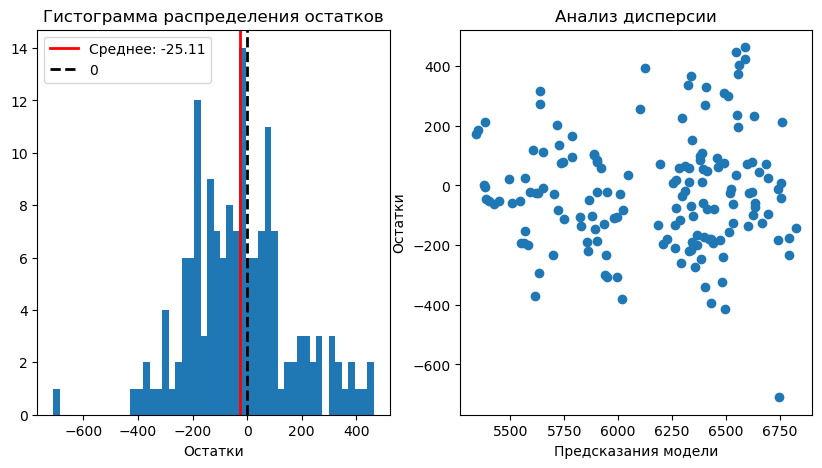

In [109]:
predictions_2, test_y_2, r2_2, model_lr_2, scaler_2, encoder_2 = train_lr(ferma_main,
         ['age', 'breed', 'pasture_type', 'father_breed', 'spo_bool'],
         ['ake', 'raw_protein', 'ake_squared'], 'milk_kg')
print(f'r2 = {r2_2}')
residuals_plot(predictions_2, test_y_2)

- $r^2$ увеличился
- у гистограммы внешне немного уменьшилась дисперсия, стало видно отклонение влево
- диаграмма рассеяния стала более равномерной

### Третья модель

Добавим признак `Имя Папы` (`father_name`) из таблицы `ferma_dad`

In [110]:
ferma_main = ferma_main.merge(ferma_dad, on='id')

In [111]:
ferma_main.head()

,id,milk_kg,ake,raw_protein,spo,breed,pasture_type,father_breed,fat,protein,milk_taste,age,spo_bool,ake_squared,father_name
0,1,5863,14.2,1743,0.890,айдиал,равнинное,айдиал,3.58,3.076,вкусно,более_2_лет,False,201.64,Буйный
1,2,5529,12.8,2138,0.890,айдиал,равнинное,соверин,3.54,3.079,вкусно,менее_2_лет,False,163.84,Соловчик
2,3,5810,14.0,1854,0.885,соверин,холмистое,соверин,3.59,3.074,не вкусно,более_2_лет,False,196.00,Барин
3,4,5895,12.4,2012,0.885,соверин,холмистое,айдиал,3.40,3.075,не вкусно,более_2_лет,False,153.76,Буйный
4,5,5302,12.8,1675,0.885,айдиал,равнинное,соверин,3.73,3.073,вкусно,менее_2_лет,False,163.84,Барин


Обучим модель, вычислим метрику $r^2$ и проанализируем остатки

r2 = 0.828830558483552


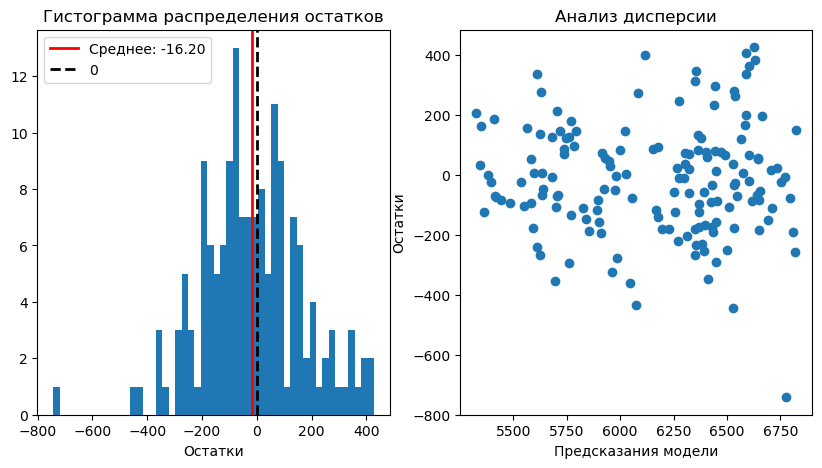

In [112]:
predictions_3, test_y_3, r2_3, model_lr_3, scaler_3, encoder_3 = train_lr(ferma_main,
         ['age', 'breed', 'pasture_type', 'father_breed', 'spo_bool', 'father_name'],
         ['ake', 'raw_protein', 'ake_squared'], 'milk_kg')
print(f'r2 = {r2_3}')
residuals_plot(predictions_3, test_y_3)

$r^2$ немного увеличился, графики остатков принципиально не поменялись

### Анализ всех трёх моделей

По метрике $r^2$ лучшая модель - третья

Рассчитаем метрики MSE, MAE, RMSE для всех трёх моделей

In [113]:
mse_1 = round(mean_squared_error(test_y_1, predictions_1), 2)
mse_2 = round(mean_squared_error(test_y_2, predictions_2), 2)
mse_3 = round(mean_squared_error(test_y_3, predictions_3), 2)

rmse_1 = round(root_mean_squared_error(test_y_1, predictions_1), 2)
rmse_2 = round(root_mean_squared_error(test_y_2, predictions_2), 2)
rmse_3 = round(root_mean_squared_error(test_y_3, predictions_3), 2)

mae_1 = round(mean_absolute_error(test_y_1, predictions_1), 2)
mae_2 = round(mean_absolute_error(test_y_2, predictions_2), 2)
mae_3 = round(mean_absolute_error(test_y_3, predictions_3), 2)

display(pd.DataFrame([[mse_1, rmse_1, mae_1, r2_1], [mse_2, rmse_2, mae_2, r2_2], [mse_3, rmse_3, mae_3, r2_3]],
                      columns=['MSE', 'RMSE', 'MAE', 'r2'], index=[1,2,3]))

,MSE,RMSE,MAE,r2
1,43887.02,209.49,164.24,0.784408
2,37187.22,192.84,150.77,0.817320
3,34844.10,186.67,145.51,0.828831


По данным метрикам третья модель также самая лучшая.

В целевом признаке `milk_kg` нет больших выбросов $\implies$ в качестве средней ошибки модели следует рассматривать метрику RMSE $\implies$ модель в среднем ошибается на 186.7 кг молока.

Расчитаем доверительный интервал

In [114]:
lower_quantile = np.quantile(test_y_3 - predictions_3, 0.025)
upper_quantile = np.quantile(test_y_3 - predictions_3, 0.975)

print(f'Доверительный интервал: {lower_quantile}, {upper_quantile}')

Доверительный интервал: -354.19886855059156, 367.03321343774064


### Прогнозирование удоя

In [115]:
for feature in ['ake', 'spo', 'raw_protein']:
    cow_buy[feature] = ferma_main[feature].mean() * 1.05

In [116]:
cow_buy.head()

,breed,pasture_type,father_breed,father_name,fat,protein,age,ake,spo,raw_protein
0,айдиал,холмистое,айдиал,Геркулес,3.58,3.076,более_2_лет,15.276162,0.958744,2019.947532
1,айдиал,равнинное,соверин,Буйный,3.54,3.081,менее_2_лет,15.276162,0.958744,2019.947532
2,соверин,равнинное,соверин,Барин,3.59,3.074,более_2_лет,15.276162,0.958744,2019.947532
3,соверин,холмистое,айдиал,Буйный,3.40,3.061,более_2_лет,15.276162,0.958744,2019.947532
4,соверин,равнинное,айдиал,Буйный,3.64,3.074,более_2_лет,15.276162,0.958744,2019.947532


Подготовка данных

In [117]:
cow_buy_temp = cow_buy

Переведём `spo` в булевый тип по такому же признаку, что и выше, тогда везьде будет True

In [118]:
cow_buy_temp['spo_bool'] = True
cow_buy_temp['ake_squared'] = cow_buy_temp['ake'] ** 2

In [119]:
cow_buy_temp.head()

,breed,pasture_type,father_breed,father_name,fat,protein,age,ake,spo,raw_protein,spo_bool,ake_squared
0,айдиал,холмистое,айдиал,Геркулес,3.58,3.076,более_2_лет,15.276162,0.958744,2019.947532,True,233.361138
1,айдиал,равнинное,соверин,Буйный,3.54,3.081,менее_2_лет,15.276162,0.958744,2019.947532,True,233.361138
2,соверин,равнинное,соверин,Барин,3.59,3.074,более_2_лет,15.276162,0.958744,2019.947532,True,233.361138
3,соверин,холмистое,айдиал,Буйный,3.40,3.061,более_2_лет,15.276162,0.958744,2019.947532,True,233.361138
4,соверин,равнинное,айдиал,Буйный,3.64,3.074,более_2_лет,15.276162,0.958744,2019.947532,True,233.361138


In [120]:
cow_buy_scaled = scaler_3.transform(cow_buy_temp[['ake', 'raw_protein', 'ake_squared']])
cow_buy_ohe = encoder_3.transform(cow_buy_temp[['age', 'breed', 'pasture_type',
                                            'father_breed', 'spo_bool', 'father_name']])
cow_buy_scaled = pd.DataFrame(cow_buy_scaled, columns=['ake', 'raw_protein', 'ake_squared'])
cow_buy_ohe = pd.DataFrame(cow_buy_ohe, columns=encoder_3.get_feature_names_out())

cow_buy_temp = pd.concat([cow_buy_ohe, cow_buy_scaled], axis=1)

In [121]:
cow_buy['milk_kg'] = model_lr_3.predict(cow_buy_temp)

In [122]:
display(cow_buy.head())

,breed,pasture_type,father_breed,father_name,fat,protein,age,ake,spo,raw_protein,spo_bool,ake_squared,milk_kg
0,айдиал,холмистое,айдиал,Геркулес,3.58,3.076,более_2_лет,15.276162,0.958744,2019.947532,True,233.361138,6581.069175
1,айдиал,равнинное,соверин,Буйный,3.54,3.081,менее_2_лет,15.276162,0.958744,2019.947532,True,233.361138,6308.701838
2,соверин,равнинное,соверин,Барин,3.59,3.074,более_2_лет,15.276162,0.958744,2019.947532,True,233.361138,6263.024906
3,соверин,холмистое,айдиал,Буйный,3.40,3.061,более_2_лет,15.276162,0.958744,2019.947532,True,233.361138,6571.763131
4,соверин,равнинное,айдиал,Буйный,3.64,3.074,более_2_лет,15.276162,0.958744,2019.947532,True,233.361138,6525.082196


Найдём количество коров удовлетворяющих условию (удой > 6000) с учётом доверительного интервала

In [123]:
print(cow_buy.query('milk_kg > (6000 + @upper_quantile)')['milk_kg'].count())

10


### Вывод

Были обучены три модели линейной регрессии для предсказания значения удоя. Была выбрана лучшая со значением метрики $r^2$ равным 0.83, средней ошибкой 186.7 кг и доверительным интервалом $[-354.2, 367.0]$.

С помощью модели были предсказаны значения удоя. По условию (удой > 6000) c учётом доверительного интервала нам подходят 8 коров.

## Обучение модели логистической регрессии

### Подготовка даных

In [124]:
ferma_main['taste_bool'] = (ferma_main['milk_taste'] == 'вкусно')

### Обучение модели

Обучим модель и рассчитаем метрики accuracy, precision и recall

In [493]:
model_logreg = LogisticRegression()
model_logreg.fit(X_train, y_train)
predictions = model_logreg.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')

Accuracy: 0.63
Precision: 0.62
Recall: 0.86


В данном случае хуже купить корову с невкусным молоком, чем не купить с вкусным, $\implies$ нас интересуют ошибки 1-го рода $\implies$ следует в первую очередь оценивать метрику precision

Построим матрицу ошибок

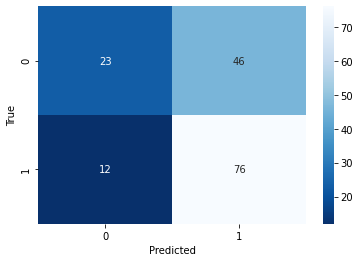

In [494]:
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

Результаты удручающие, попроуем поменять порог классификации

In [495]:
y_proba = model_logreg.predict_proba(X_test)[:, 1]
thresholds = [round(i,2) for i in np.linspace(0.1,1,num=20,endpoint=False)]

data = pd.DataFrame(zip(y_test, y_proba), columns = ['y_valid',
                                'y_proba']).sort_values(by='y_proba', ascending=False)

columns = []
for i in thresholds:
    columns.append('y_pred_'+str(i))
    data['y_pred'+str(i)] = data['y_proba'].apply(lambda x: 1 if x >= i else 0)
display(data.head(10))

,y_valid,y_proba,y_pred0.1,y_pred0.15,y_pred0.19,y_pred0.24,y_pred0.28,y_pred0.32,y_pred0.37,y_pred0.42,...,y_pred0.55,y_pred0.6,y_pred0.64,y_pred0.68,y_pred0.73,y_pred0.77,y_pred0.82,y_pred0.86,y_pred0.91,y_pred0.96
85,True,0.857896,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,0,0,0
66,True,0.842972,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,0,0,0
110,True,0.837533,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,0,0,0
51,True,0.835546,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,0,0,0
8,True,0.812785,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,0,0,0,0
147,True,0.807715,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,0,0,0,0
136,True,0.807182,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,0,0,0,0
108,False,0.803590,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,0,0,0,0
114,True,0.795781,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,0,0,0,0
54,False,0.794727,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,0,0,0,0


Построим таблицу метрик accuracy и precision при различных порогах классификации

In [496]:
pd.DataFrame([['y_pred'+str(x), round(accuracy_score(data['y_valid'], data['y_pred'+str(x)]), 2),
               round(precision_score(data['y_valid'], data['y_pred'+str(x)]), 2)] for x in thresholds],
             columns=['threshold', 'accuracy', 'precision'])
    

,threshold,accuracy,precision
0,y_pred0.1,0.56,0.56
1,y_pred0.15,0.56,0.56
2,y_pred0.19,0.56,0.56
3,y_pred0.24,0.56,0.56
4,y_pred0.28,0.57,0.56
5,y_pred0.32,0.57,0.57
6,y_pred0.37,0.57,0.57
7,y_pred0.42,0.57,0.57
8,y_pred0.46,0.59,0.59
9,y_pred0.5,0.63,0.62


Значение с максимальным precision 0.82, но возьмём значение 0.78, чтобы модель была одекватной

In [497]:
threshold_res = 0.80

Построим матрицу ошибок

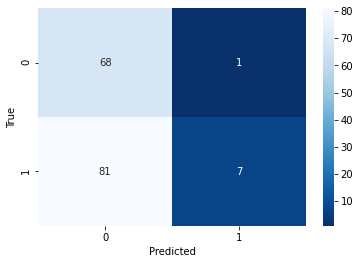

In [498]:
cm = confusion_matrix(y_test, [prob > threshold_res for prob in y_proba])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

При данном пороге есть всего один ложноположительный ответ

### Прогнозирование вкуса молока

In [499]:
cow_buy.head()

,breed,pasture_type,father_breed,father_name,fat,protein,age,ake,spo,raw_protein,spo_bool,ake_squared,milk_kg
0,айдиал,холмистое,айдиал,Геркулес,3.58,3.076,более_2_лет,15.276162,0.958744,2019.947532,True,233.361138,6038.878183
1,айдиал,равнинное,соверин,Буйный,3.54,3.081,менее_2_лет,15.276162,0.958744,2019.947532,True,233.361138,5152.798419
2,соверин,равнинное,соверин,Барин,3.59,3.074,более_2_лет,15.276162,0.958744,2019.947532,True,233.361138,6375.429857
3,соверин,холмистое,айдиал,Буйный,3.40,3.061,более_2_лет,15.276162,0.958744,2019.947532,True,233.361138,5464.260904
4,соверин,равнинное,айдиал,Буйный,3.64,3.074,более_2_лет,15.276162,0.958744,2019.947532,True,233.361138,5174.120428


Подготовка данных

In [500]:
cow_buy_temp = cow_buy

cow_buy_scaled = scaler_logreg.transform(cow_buy_temp[num_cols])
cow_buy_ohe = encoder_logreg.transform(cow_buy_temp[cat_cols])

cow_buy_scaled = pd.DataFrame(cow_buy_scaled, columns=num_cols)
cow_buy_ohe = pd.DataFrame(cow_buy_ohe, columns=encoder_logreg.get_feature_names())

cow_buy_temp = pd.concat([cow_buy_scaled, cow_buy_ohe], axis=1)

Предсказание вкуса молока

In [501]:
predictions = model_logreg.predict_proba(cow_buy_temp)[:, 1]
cow_buy['milk_taste'] = ['вкусно' if pred > threshold_res else 'не вкусно' for pred in predictions]

In [502]:
cow_buy['milk_taste'].value_counts()

не вкусно    20
Name: milk_taste, dtype: int64

### Вывод

Была построена и обучена модель логистической регрессии

С помощью этой модели был предсказан вкус молока коров

## Итоговые выводы

### Итоговый список коров

Отберём в отдельный датафрейм коров из `cow_buy`, у которых удой больше 6000 с учётом доверительного интервала и вкусное молоко

In [503]:
cow_buy_res = cow_buy.query('milk_kg > (6000 + @upper_quantile) and milk_taste == "вкусно"')
cow_buy_res

,breed,pasture_type,father_breed,father_name,fat,protein,age,ake,spo,raw_protein,spo_bool,ake_squared,milk_kg,milk_taste


У "ЭкоФерма" нет коров, подходящих по критериям заказчику

### Вывод

По полученным данным была проведена следующая работа

**Предобработка данных**:

В таблицах `ferma_main` присутствуют дублирующиеся строки, что скорее всего вызвано технической ошибкой. В столбцах с породами коров и типами пастбищ есть неявные дубликаты, что скорее всего вызвано человеческим фактором, заказчику рекомендуется более ответственно подходитиь к унификации вышеупомянутых данных.

Что было сделано:
- Изменены названия столбцов
- Обработаны неявные дубликаты в столбцах пород и типов пастбищ
- Удалены дублирующиеся строки в таблицах `ferma_main`

**Исследовательский аналих данных**:

В датасете была корова с аномально большим удоем, это скорее всего было вызвано человеческим фактором или технической ошибкой.

Из количественных признаков распределены нормально:
- удой (`milk_kg`)
- ЭКЕ (`ake`)
- белок (`protein`)

Ненормально:
- сырой протеин (`raw_protein`)
- СПО (`spo`)
- жирность (`fat`)

**Корреляционный анализ**:

У удоя (`milk_kg`) коэффициент корреляции больше 0.9 только с возрастом (`age`) $\implies$ мультиколлинеарности не наблюдается.

По диаграммам рассеяния видны нелинейные связи с `spo` (данные сбиваются в два кластера) и с `protein`. В `ake` зависимость похожа на квадратичную

**Обучение модели линейной регрессии**:

Были обучены три модели линейной регрессии для предсказания значения удоя. Была выбрана лучшая со значением метрики $r^2$ равным 0.83, средней ошибкой 186.7 кг и доверительным интервалом $[-354.2, 367.0]$.

С помощью модели были предсказаны значения удоя. По условию (удой > 6000) c учётом доверительного интервала нам подходят 8 коров.

**Обучени модели логистической регрессии**:

Была построена и обучена модель логистической регрессии с порогом классификации 0.80

С помощью этой модели был предсказан вкус молока коров

**Итоговый список коров**:

У "ЭкоФерма" нет коров, у которых было бы вкусное молоко

**Рекоендации заказчику**

Модель классификации получилась довольно низкого качества. Для её улучшения рекомендуется сделать больше входных признаков